# Learning from Time-Changing Data with Adaptive Windowing (ADWIN2)

This notebook implements a toy version of the ADWIN2 algorithm for detecting distribution changes in data streams. ADWIN2 maintains an adaptive sliding window that automatically shrinks when a change in the data distribution is detected using Hoeffding bounds. We demonstrate this on a synthetic Bernoulli stream where the probability changes over time, and compare ADWIN2's adaptive windowing to fixed-size windows.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import math

torch.manual_seed(0)
np.random.seed(0)

## Dataset Description

We generate a synthetic Bernoulli bit stream of 10,000 samples where the success probability μ changes over time:
- Steps 0-4999: μ = 0.2 (stable low probability)
- Steps 5000-9999: μ linearly increases from 0.2 to 0.8 (gradual drift)

This simulates a concept drift scenario where ADWIN2 should adapt its window size to detect the change.

In [2]:
# Generate synthetic Bernoulli stream with changing probability
N_SAMPLES = 10000
CHANGE_POINT = 5000

# True probabilities over time
true_mu = np.zeros(N_SAMPLES)
true_mu[:CHANGE_POINT] = 0.2
true_mu[CHANGE_POINT:] = np.linspace(0.2, 0.8, N_SAMPLES - CHANGE_POINT)

# Generate Bernoulli samples
data_stream = (np.random.rand(N_SAMPLES) < true_mu).astype(float)

print(f"Generated {N_SAMPLES} samples")
print(f"First 1000 samples mean: {data_stream[:1000].mean():.3f} (expected ~0.2)")
print(f"Last 1000 samples mean: {data_stream[-1000:].mean():.3f} (expected ~0.7-0.8)")

Generated 10000 samples
First 1000 samples mean: 0.200 (expected ~0.2)
Last 1000 samples mean: 0.721 (expected ~0.7-0.8)


## ADWIN2 Algorithm Description

ADWIN2 maintains a sliding window W and compresses it using buckets of exponential sizes. Key equations:

1. **Harmonic mean**: $m = \frac{1}{\frac{1}{n_0} + \frac{1}{n_1}}$ for subwindow lengths $n_0, n_1$
2. **Bonferroni correction**: $\delta' = \frac{\delta}{\ln(n)}$ for multiple hypothesis testing
3. **Change threshold**: $\epsilon_{cut} = \sqrt{\frac{1}{2m} \ln\frac{4}{\delta'}}$ (Hoeffding bound)
4. **Change detection**: If $|\mu_{W_0} - \mu_{W_1}| \geq \epsilon_{cut}$, shrink window

The algorithm tests all bucket boundaries and removes old data when a significant change is detected.

In [3]:
class Bucket:
    """Represents a bucket with size and sum of elements."""
    def __init__(self, size=0, total=0.0):
        self.size = size
        self.total = total

class ADWIN2:
    """ADWIN2 adaptive sliding window for change detection."""
    def __init__(self, delta=0.002, M=5):
        self.delta = delta
        self.M = M  # Max buckets per size
        self.buckets = []  # List of buckets, oldest first
        self.total = 0.0
        self.width = 0
        self.change_detected = False
        
    def add_element(self, value):
        """Add new element to window head."""
        self.change_detected = False
        
        # Add new bucket of size 1
        self.buckets.append(Bucket(size=1, total=float(value)))
        self.total += value
        self.width += 1
        
        # Compress buckets
        self._compress_buckets()
        
        # Detect change
        self._detect_change()
        
    def _compress_buckets(self):
        """Merge buckets when M+1 of same size exist."""
        i = len(self.buckets) - 1
        while i >= self.M:
            # Check if M+1 buckets of same size exist
            if i >= self.M:
                # Count buckets of same size as buckets[i]
                current_size = self.buckets[i].size
                count = 0
                for j in range(len(self.buckets) - 1, -1, -1):
                    if self.buckets[j].size == current_size:
                        count += 1
                    else:
                        break
                
                # If M+1 buckets of same size, merge two oldest
                if count > self.M:
                    # Find the two oldest buckets of this size
                    merge_idx = len(self.buckets) - count
                    b1 = self.buckets[merge_idx]
                    b2 = self.buckets[merge_idx + 1]
                    
                    # Create merged bucket
                    merged = Bucket(size=b1.size + b2.size, total=b1.total + b2.total)
                    
                    # Remove old buckets and insert merged
                    self.buckets.pop(merge_idx + 1)
                    self.buckets.pop(merge_idx)
                    self.buckets.insert(merge_idx, merged)
            i -= 1
    
    def _detect_change(self):
        """Test all cutpoints for distribution change."""
        if self.width < 2:
            return
        
        n = self.width
        # Test each bucket boundary as a cutpoint
        n0 = 0
        sum0 = 0.0
        
        for i in range(len(self.buckets) - 1):  # Don't cut off the newest bucket
            n0 += self.buckets[i].size
            sum0 += self.buckets[i].total
            n1 = n - n0
            sum1 = self.total - sum0
            
            if n0 >= 1 and n1 >= 1:
                mu0 = sum0 / n0
                mu1 = sum1 / n1
                
                # Harmonic mean
                m = 1.0 / (1.0/n0 + 1.0/n1)
                
                # Bonferroni correction
                delta_prime = self.delta / math.log(n) if n > 1 else self.delta
                
                # Hoeffding bound threshold
                epsilon_cut = math.sqrt((1.0 / (2.0 * m)) * math.log(4.0 / delta_prime))
                
                # Check for change
                if abs(mu0 - mu1) >= epsilon_cut:
                    # Drop oldest buckets up to this cutpoint
                    for _ in range(i + 1):
                        dropped = self.buckets.pop(0)
                        self.width -= dropped.size
                        self.total -= dropped.total
                    self.change_detected = True
                    break
    
    def get_mean(self):
        """Get current mean estimate."""
        return self.total / self.width if self.width > 0 else 0.0
    
    def get_width(self):
        """Get current window width."""
        return self.width

In [4]:
# Run ADWIN2 and fixed windows on the data stream
print("Running ADWIN2 algorithm...")

adwin = ADWIN2(delta=0.002, M=5)
fixed_32 = deque(maxlen=32)
fixed_512 = deque(maxlen=512)

# Track results
adwin_means = []
adwin_widths = []
fixed_32_means = []
fixed_512_means = []
changes_detected = []

for t, value in enumerate(data_stream):
    # ADWIN2
    adwin.add_element(value)
    adwin_means.append(adwin.get_mean())
    adwin_widths.append(adwin.get_width())
    if adwin.change_detected:
        changes_detected.append(t)
    
    # Fixed windows
    fixed_32.append(value)
    fixed_512.append(value)
    fixed_32_means.append(np.mean(fixed_32) if len(fixed_32) > 0 else 0.0)
    fixed_512_means.append(np.mean(fixed_512) if len(fixed_512) > 0 else 0.0)

adwin_means = np.array(adwin_means)
adwin_widths = np.array(adwin_widths)
fixed_32_means = np.array(fixed_32_means)
fixed_512_means = np.array(fixed_512_means)

print(f"Completed processing {N_SAMPLES} samples")
print(f"Number of changes detected: {len(changes_detected)}")
print(f"Changes detected at steps: {changes_detected[:10]}...")  # Show first 10

Running ADWIN2 algorithm...


Completed processing 10000 samples
Number of changes detected: 4
Changes detected at steps: [5914, 7109, 7982, 9417]...


In [5]:
# Evaluation metrics

# Mean Squared Error for each method
mse_adwin = np.mean((adwin_means - true_mu) ** 2)
mse_fixed_32 = np.mean((fixed_32_means - true_mu) ** 2)
mse_fixed_512 = np.mean((fixed_512_means - true_mu) ** 2)

print("\n=== Evaluation Metrics ===")
print(f"Mean Squared Error (MSE):")
print(f"  ADWIN2:       {mse_adwin:.6f}")
print(f"  Fixed-32:     {mse_fixed_32:.6f}")
print(f"  Fixed-512:    {mse_fixed_512:.6f}")

# Detection delay - time to first detection after change point
detections_after_change = [t for t in changes_detected if t >= CHANGE_POINT]
if detections_after_change:
    detection_delay = detections_after_change[0] - CHANGE_POINT
    print(f"\nDetection delay: {detection_delay} steps after change point")
else:
    print(f"\nNo change detected after change point")

# Average window width
avg_width = np.mean(adwin_widths)
print(f"Average ADWIN2 window width: {avg_width:.1f}")
print(f"Max ADWIN2 window width: {np.max(adwin_widths)}")
print(f"Min ADWIN2 window width: {np.min(adwin_widths)}")


=== Evaluation Metrics ===
Mean Squared Error (MSE):
  ADWIN2:       0.001723
  Fixed-32:     0.005824
  Fixed-512:    0.000661

Detection delay: 914 steps after change point
Average ADWIN2 window width: 2189.1
Max ADWIN2 window width: 5914
Min ADWIN2 window width: 1


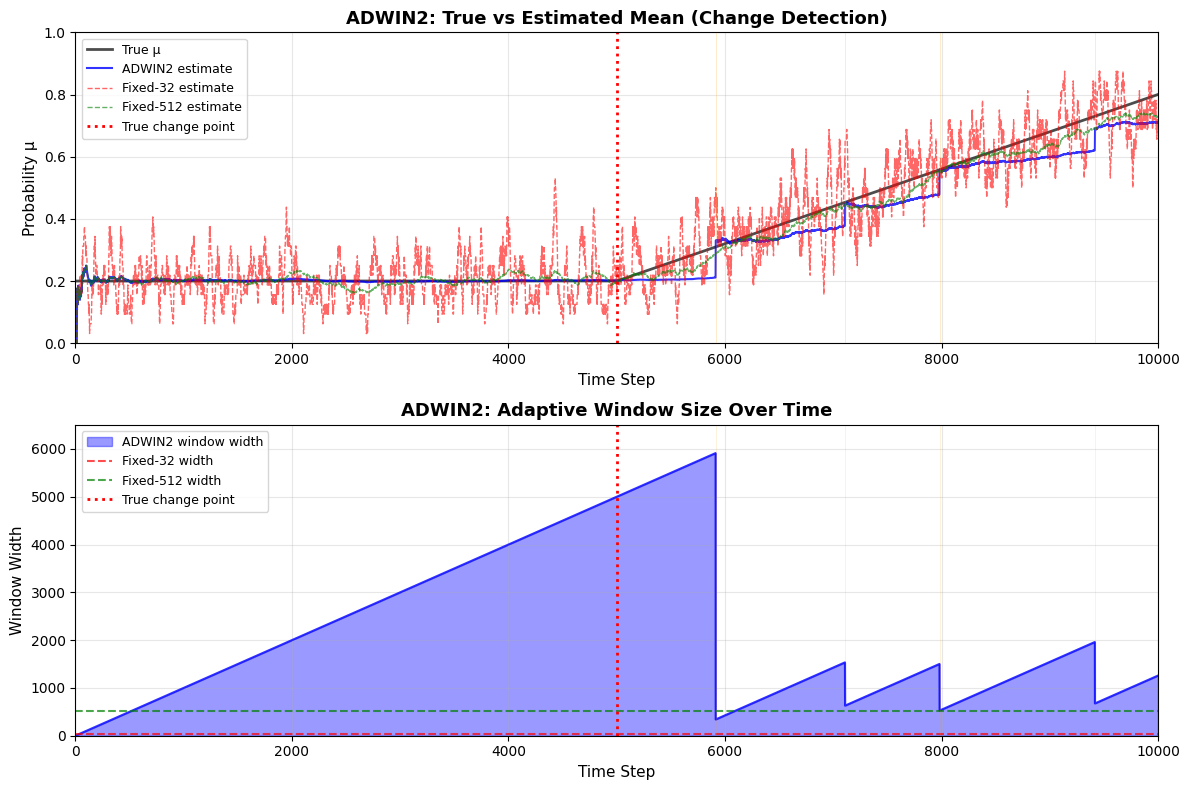

In [6]:
# Create key figure showing adaptive windowing behavior
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: True mu vs estimates
time_steps = np.arange(N_SAMPLES)
ax1.plot(time_steps, true_mu, 'k-', linewidth=2, label='True μ', alpha=0.7)
ax1.plot(time_steps, adwin_means, 'b-', linewidth=1.5, label='ADWIN2 estimate', alpha=0.8)
ax1.plot(time_steps, fixed_32_means, 'r--', linewidth=1, label='Fixed-32 estimate', alpha=0.6)
ax1.plot(time_steps, fixed_512_means, 'g--', linewidth=1, label='Fixed-512 estimate', alpha=0.6)

# Mark change detections
for t in changes_detected[:50]:  # Limit markers for visibility
    ax1.axvline(x=t, color='orange', alpha=0.3, linewidth=0.5)

ax1.axvline(x=CHANGE_POINT, color='red', linestyle=':', linewidth=2, label='True change point')
ax1.set_xlabel('Time Step', fontsize=11)
ax1.set_ylabel('Probability μ', fontsize=11)
ax1.set_title('ADWIN2: True vs Estimated Mean (Change Detection)', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, N_SAMPLES)
ax1.set_ylim(0, 1)

# Plot 2: Window width over time
ax2.fill_between(time_steps, 0, adwin_widths, alpha=0.4, color='blue', label='ADWIN2 window width')
ax2.plot(time_steps, adwin_widths, 'b-', linewidth=1.5, alpha=0.8)
ax2.axhline(y=32, color='r', linestyle='--', linewidth=1.5, label='Fixed-32 width', alpha=0.7)
ax2.axhline(y=512, color='g', linestyle='--', linewidth=1.5, label='Fixed-512 width', alpha=0.7)
ax2.axvline(x=CHANGE_POINT, color='red', linestyle=':', linewidth=2, label='True change point')

# Mark significant window drops
for t in changes_detected[:50]:
    ax2.axvline(x=t, color='orange', alpha=0.2, linewidth=0.5)

ax2.set_xlabel('Time Step', fontsize=11)
ax2.set_ylabel('Window Width', fontsize=11)
ax2.set_title('ADWIN2: Adaptive Window Size Over Time', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, N_SAMPLES)
ax2.set_ylim(0, max(adwin_widths) * 1.1)

plt.tight_layout()
plt.show()

## What to Look For in the Figure

**Top plot**: Shows how well each method estimates the true probability μ. ADWIN2 (blue) should track the true probability (black) more closely than fixed windows during the drift phase (after step 5000). Orange vertical lines mark detected changes.

**Bottom plot**: Demonstrates ADWIN2's adaptive behavior. The window width (blue shaded area) grows during stable periods and shrinks when changes are detected. Notice the window drops (vertical orange lines) occurring around and after the change point (red dotted line at step 5000), showing ADWIN2 automatically adapting to the concept drift by reducing its window size to focus on recent, relevant data.